## 1. Prep Data for Combined UMAP

In [1]:
import pandas as pd

In [2]:
GAME_XY_PATH = "../file_processing/processed/xy_data.parquet"

In [3]:
game_xy_df = pd.read_parquet(GAME_XY_PATH)

game_xy_df["vase_id"] = (
    game_xy_df["participant_id"].astype(str)
    + "::"
    + game_xy_df["generation_key"].astype(str)
    + "::"
    + game_xy_df["vase"].astype(str)
)

In [4]:
GAME_PC_PATH = "../file_processing/processed/pc_data.parquet"

In [5]:
game_df = pd.read_parquet(GAME_PC_PATH)
game_df['source'] = 'game'
game_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'Game latent DataFrame shape: {game_df.shape}')
game_df.head()

Game latent DataFrame shape: (299700, 22)


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,source
0,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
1,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
2,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
3,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
4,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game


In [6]:
game_df["vase_id"] = (
    game_df["participant_id"].astype(str)
    + "::"
    + game_df["generation_key"].astype(str)
    + "::"
    + game_df["vase"].astype(str)
)

In [8]:
game_pc_wide = (
    game_df
    .pivot_table(index='vase_id', columns='pc_name', values='pc_value', aggfunc='first')
    .reset_index()
)
game_pc_wide.columns.name = None
game_pc_wide['source'] = 'game'
game_pc_wide['culture_general'] = None  # not available for game vases

pc_cols = sorted([c for c in game_pc_wide.columns if c.startswith('PC')])
game_pc_wide = game_pc_wide[pc_cols + ['vase_id', 'culture_general', 'source']]

print(f'Game PC wide shape: {game_pc_wide.shape}')
game_pc_wide.head()

Game PC wide shape: (49950, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game


In [9]:
game_latent_df = game_pc_wide[[ c for c in game_pc_wide.columns if c.startswith('PC') ]]
game_latent_df['source'] = 'game'
game_latent_df['vase_id'] = game_pc_wide['vase_id']
game_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...


In [10]:
latent_df = game_latent_df.copy()
print(f'Latent DataFrame shape: {latent_df.shape}')
print(latent_df['source'].value_counts())
latent_df.head()

Latent DataFrame shape: (49950, 8)
source
game    49950
Name: count, dtype: int64


,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...


## 2. Optimise UMAP Projection

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.manifold import trustworthiness
from tqdm import tqdm

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# [LATENT] Process all latent dimensions into an array for UMAP
latent_cols = [ c for c in latent_df.columns if c.startswith('PC') ]
latent_array = latent_df[latent_cols].values
print(f'Latent array shape: {latent_array.shape}')

Latent array shape: (49950, 6)


In [13]:
# # [XY] Build per-vase XY feature matrix for UMAP
# # Each vase is represented as a flattened vector: [x0, x1, ..., xN, y0, y1, ..., yN]
# # sorted by point_order so coordinate positions are consistent across vases.

# def build_xy_feature_matrix(df, id_col='vase_id', order_col='point_order'):
#     rows, ids, sources = [], [], []
#     for (vase_id, source), grp in df.groupby([id_col, 'source'], sort=False):
#         grp_sorted = grp.sort_values(order_col) if order_col in grp.columns else grp
#         x = grp_sorted['x'].to_numpy(dtype=np.float32)
#         y = grp_sorted['y'].to_numpy(dtype=np.float32)
#         rows.append(np.concatenate([x, y]))
#         ids.append(vase_id)
#         sources.append(source)
#     return np.stack(rows), pd.DataFrame({'vase_id': ids, 'source': sources})

# xy_matrix_real, meta_real = build_xy_feature_matrix(real_df)
# xy_matrix_game, meta_game = build_xy_feature_matrix(game_df)

# xy_array = np.vstack([xy_matrix_real, xy_matrix_game])
# xy_meta_df = pd.concat([meta_real, meta_game], ignore_index=True)

# print(f'XY feature matrix shape: {xy_array.shape}')  # (n_vases, 500)
# print(xy_meta_df['source'].value_counts())

In [14]:
def umap_calibration(latent_matrix, sample_size=15000, n_neighbors_test = [15, 50, 150, 200], min_dist_test = [0.01, 0.1, 0.5]):
    np.random.seed(42)
    indices = np.random.choice(latent_matrix.shape[0], sample_size, replace=False)
    X_sample = latent_matrix[indices]
    
    fig, axes = plt.subplots(len(n_neighbors_test), len(min_dist_test), figsize=(18, 18))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    best_score = 0
    best_params = {}
        
    for i, n_n in tqdm(enumerate(n_neighbors_test), total=len(n_neighbors_test)):
        for j, m_d in tqdm(enumerate(min_dist_test), total=len(min_dist_test)):
            print(f"   -> Testing: n_neighbors={n_n}, min_dist={m_d}")
            
            reducer = umap.UMAP(
                n_components=2, 
                n_neighbors=n_n, 
                min_dist=m_d, 
                metric='euclidean', 
                random_state=42
            )
            umap_coords = reducer.fit_transform(X_sample)
            
            # Trustworthiness measures to what extent the local structure is retained.
            # A score of 1.0 means the 2D map perfectly represents the true latent dimensions' local relationships.
            score = trustworthiness(X_sample, umap_coords, n_neighbors=n_n)
            
            if score > best_score:
                best_score = score
                best_params = {'n_neighbors': n_n, 'min_dist': m_d}
            
            ax = axes[i, j]
            ax.scatter(umap_coords[:, 0], umap_coords[:, 1], s=1, alpha=0.3, c='black')
            ax.set_title(f"n_neighbors: {n_n} | min_dist: {m_d}\nTrustworthiness: {score:.4f}", fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.suptitle("UMAP Hyperparameter Topologies (15k Sample)", fontsize=20, y=0.92)
    plt.savefig("umap_calibration_grid.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   MATHEMATICAL OPTIMUM: n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']} (Score: {best_score:.4f})")
    
    return best_params

In [15]:
n_neighbors_test = [150, 200, 300] 
min_dist_test = [0.01, 0.02, 0.05]

In [16]:
# # [XY] Run calibration on XY feature matrix instead of latent array
# optimal_params = umap_calibration(latent_array, sample_size=15000, n_neighbors_test=n_neighbors_test, min_dist_test=min_dist_test)
# print(f"Optimal UMAP Parameters: {optimal_params}")

In [17]:
# n_n_opt = optimal_params['n_neighbors']
# m_d_opt = optimal_params['min_dist']

In [18]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=200,
    min_dist=0.02,
    metric='euclidean',
    random_state=42,
)
embedding = reducer.fit_transform(latent_array)
print('UMAP embedding shape:', embedding.shape)

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP embedding shape: (49950, 2)


In [19]:
umap_x = embedding[:, 0]
umap_y = embedding[:, 1]
latent_df['umap_x'] = umap_x  # [XY] was: latent_df['umap_x']
latent_df['umap_y'] = umap_y  # [XY] was: latent_df['umap_y']
latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id,umap_x,umap_y
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,1.391220,8.914517
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,4.899067,3.771759
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,4.896499,3.770096
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,2.793084,6.647314
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,4.901217,3.762256


In [20]:
master_df = game_df.copy()
print(f'Master DataFrame shape: {master_df.shape}')
master_df.head()

Master DataFrame shape: (299700, 23)


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,source,vase_id
0,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
1,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
2,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
3,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...
4,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...


In [21]:
# Add the UMAP coordinates to the master DataFrame
# [XY] was: master_df.merge(latent_df[['vase_id', 'source', 'umap_x', 'umap_y']], ...)
master_df = master_df.merge(latent_df[['vase_id', 'source', 'umap_x', 'umap_y']], on=['vase_id', 'source'], how='left')
print(f'Master DataFrame with UMAP shape: {master_df.shape}')
print(master_df.columns)
master_df.head()

Master DataFrame with UMAP shape: (299700, 25)
Index(['generation_key', 'vase', 'pc_name', 'pc_value', 'is_selected_vase',
       'is_parent_vase', 'selection_elapsed_time_s', 'decision_time_ms',
       'adjusted_selection_elapsed_time_s', 'adjusted_decision_time_ms',
       'rt_onset_correction_ms', 'rt_calibration_status',
       'rt_calibration_median_ms', 'rt_calibration_trials_n', 'participant_id',
       'session_id', 'play_counter', 'metadata_schema_version',
       'session_started_at', 'session_duration_s', 'completion_status',
       'source', 'vase_id', 'umap_x', 'umap_y'],
      dtype='str')


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,source,vase_id,umap_x,umap_y
0,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,8.8598,3.477431
1,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,8.8598,3.477431
2,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,8.8598,3.477431
3,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,8.8598,3.477431
4,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435,7.427,7427.0,...,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,8.8598,3.477431


## 3. Plot UMAP Projections

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np

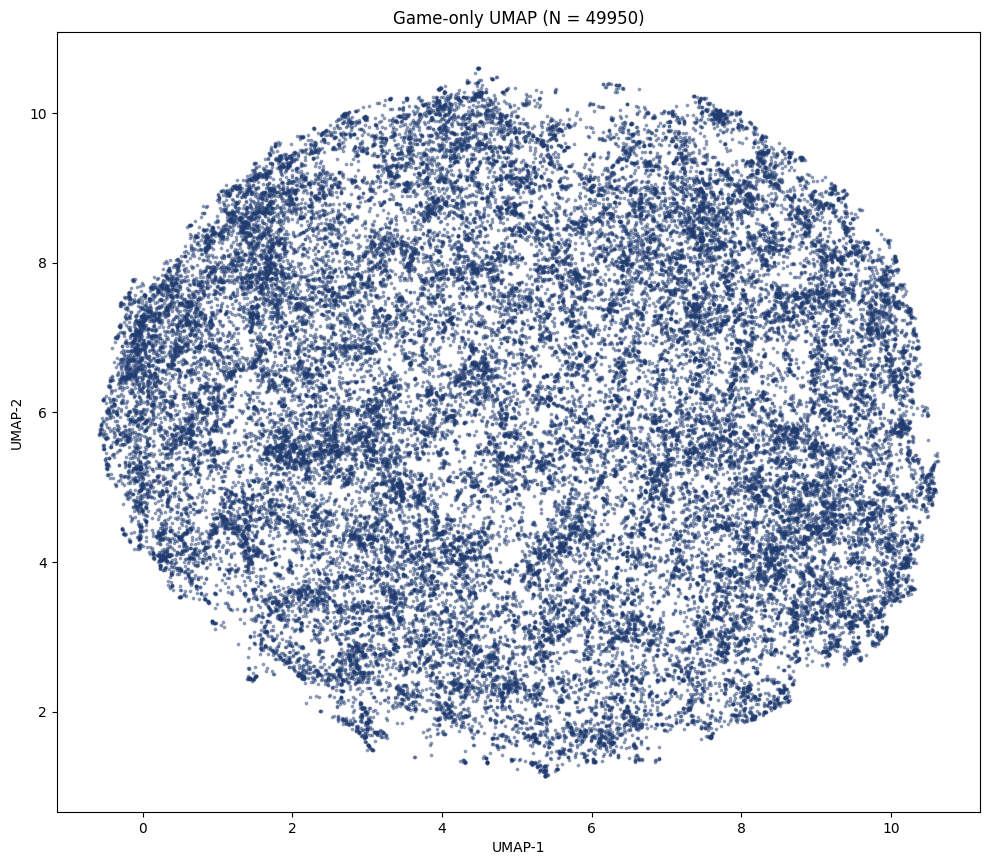

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(latent_df['umap_x'], latent_df['umap_y'], s=3, alpha=0.4, color='#1f3b70')
ax.set_title(f'Game-only UMAP (N = {len(latent_df)})')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [24]:
game_cols = ['vase_id', 'x', 'y'] + (['coord_order'] if 'coord_order' in game_xy_df.columns else [])
xy_for_plot = game_xy_df[game_cols].copy()
xy_for_plot['source'] = 'game'
xy_for_plot.head()

,vase_id,x,y,source
0,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.000650,1.977799,game
1,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.046236,1.977766,game
2,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.091811,1.977784,game
3,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.137535,1.977849,game
4,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,0.183402,1.978020,game


In [25]:
contours_by_key = {}
for (src, vase_id), grp in xy_for_plot.groupby(['source', 'vase_id'], sort=False):
    if 'coord_order' in grp.columns:
        grp = grp.sort_values('coord_order')

    x = grp['x'].to_numpy(dtype=float)
    y = grp['y'].to_numpy(dtype=float)
    if len(x) < 3:
        continue

    # Ensure closed polygon for clean fills.
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    # Normalize each vase profile to fit the draw cell consistently.
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    scale = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), 1e-9)
    x = x / scale
    y = y / scale

    contours_by_key[(src, vase_id)] = np.vstack([x, y])

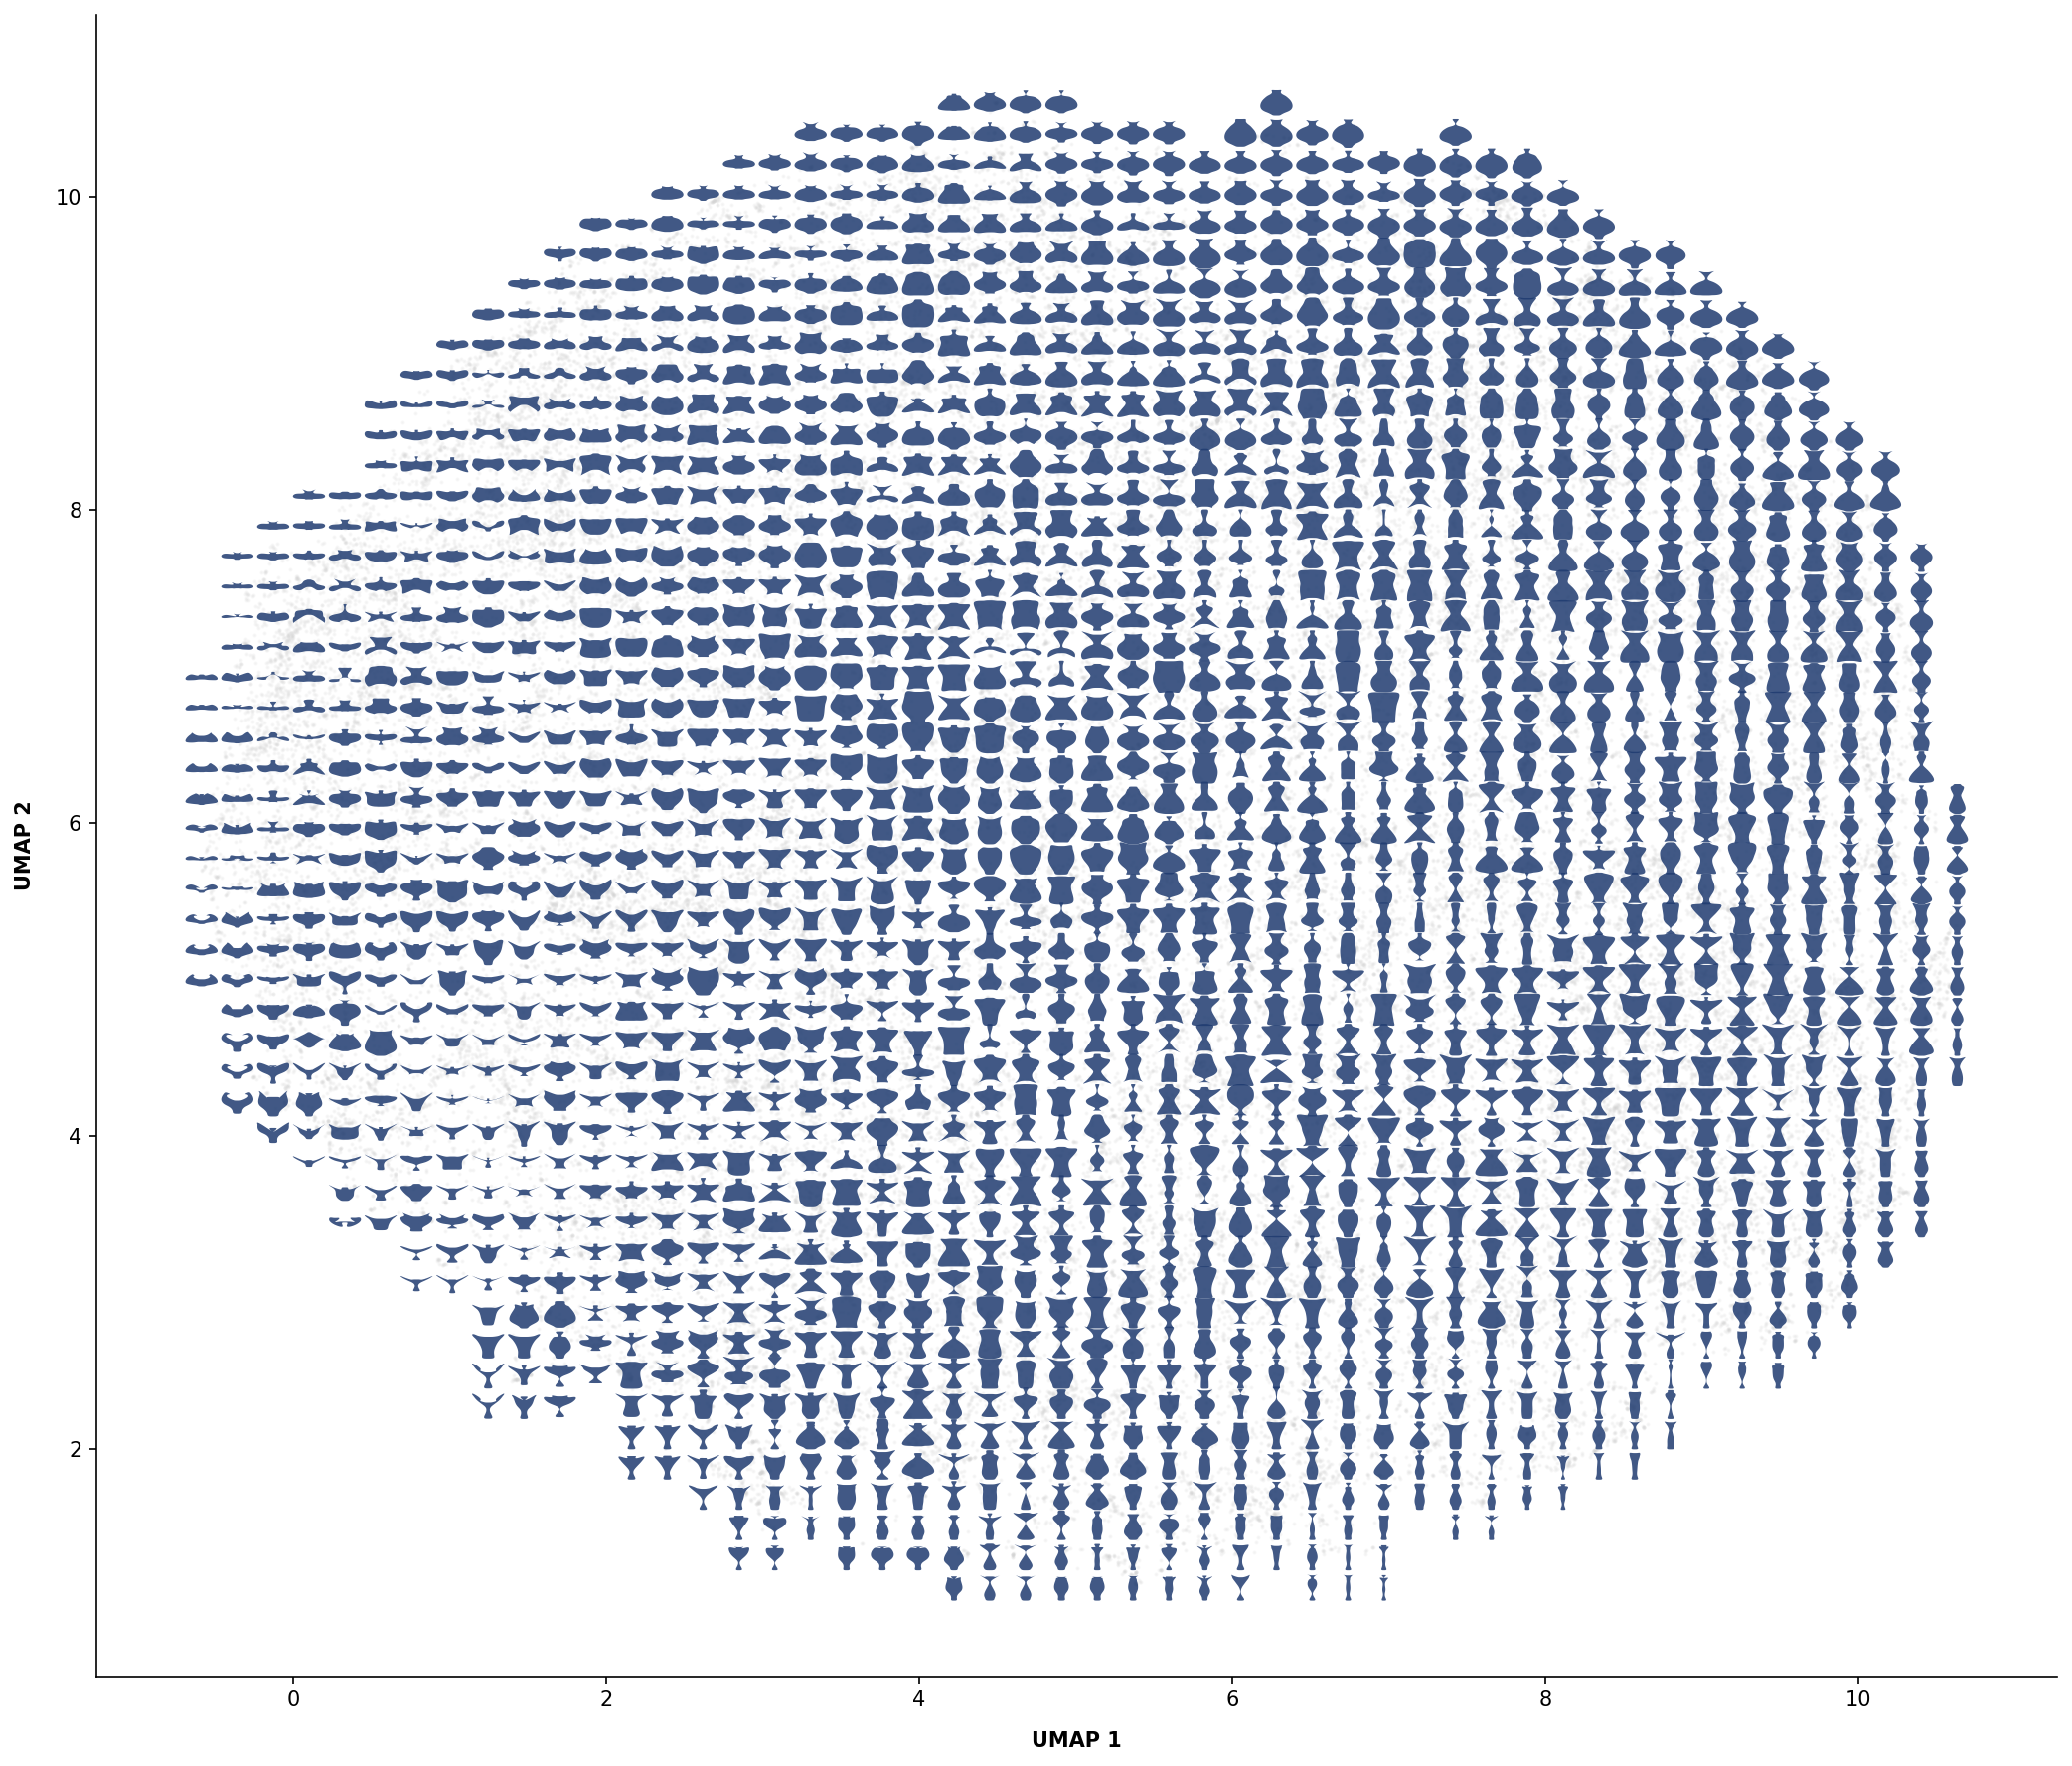

In [26]:
from scipy.spatial import cKDTree

N = 50           # grid size N×N
MAX_DIST_FACTOR = 1.0  # skip grid point if nearest vase > this × cell_width away

vase_pos = latent_df.dropna(subset=['umap_x', 'umap_y'])
xs_all = vase_pos['umap_x'].to_numpy()
ys_all = vase_pos['umap_y'].to_numpy()

tree = cKDTree(np.column_stack([xs_all, ys_all]))

x_grid = np.linspace(xs_all.min(), xs_all.max(), N)
y_grid = np.linspace(ys_all.min(), ys_all.max(), N)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

cell_w = x_grid[1] - x_grid[0]
max_dist = cell_w * MAX_DIST_FACTOR
draw_scale = cell_w * 0.45

dists, nn_idx = tree.query(grid_pts)

fig, ax = plt.subplots(figsize=(14, 14), dpi=150)
ax.scatter(xs_all, ys_all, s=1, color='lightgrey', alpha=0.15, zorder=1, rasterized=True)

for (cx, cy), dist, i in zip(grid_pts, dists, nn_idx):
    if dist > max_dist:
        continue
    row = vase_pos.iloc[i]
    src, vase_id = row['source'], row['vase_id']
    contour = contours_by_key.get((src, vase_id))
    if contour is None:
        continue
    ax.fill(cx + contour[0] * draw_scale, cy + contour[1] * draw_scale,
            color='#1f3b70', alpha=0.85, edgecolor='none', zorder=2)

ax.set_aspect('equal')
ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('vase_umap_grid_game.svg', dpi=300, bbox_inches='tight')
plt.show()

## 4. Save the UMAP Dataframes

In [27]:
import os

In [28]:
SAVE_DIR = "umap_projections"
GAME_SAVE_PATH = os.path.join(SAVE_DIR, "game_vase_umap_projection.parquet")

In [29]:
os.makedirs(SAVE_DIR, exist_ok=True)
master_df.to_parquet(MASTER_SAVE_PATH, index=False)

NameError: name 'MASTER_SAVE_PATH' is not defined

In [ ]:
game_umap_df = master_df[master_df['source'] == 'game']
game_umap_df.drop([col for col in game_umap_df.columns if col.startswith('z')], axis=1, inplace=True, errors='ignore')
game_umap_df.drop(columns=["culture_general", "culture_specific", "continent_made_found", "country_made_found"], inplace=True, errors='ignore')
game_umap_df.head()

In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)
game_umap_df.to_parquet(GAME_SAVE_PATH, index=False)